# Magnons from a pair-basis ladder
The random phase approximation of the spin response dresses a site-resolved susceptibility with a
vertex that is one number per site. That is exact for an onsite Hubbard $U$, but a neighbor-shell
interaction does not fit in it: writing $H_{int} = \tfrac12\sum V_{ij} n_i n_j$, the rung of the
transverse ladder is $K_{(ij),(kl)} = -V_{ij}\delta_{ik}\delta_{jl}$, diagonal in the pair index
$(i,j)$ rather than in the site index. `h.get_transverse_spinchi()` and
`h.get_magnon_bands(method="pair")` sum the ladder in that pair index, so a neighbor-shell
density-density interaction, or an exchange interaction with its transverse part, enters the
transverse spin response properly. Only the pairs the interaction connects enter, so a short-ranged
interaction keeps the cost linear in the number of sites.

What this route keeps, compared with the time-dependent Hartree-Fock one, is the frequency: it
returns the response $\chi(q,\omega)$ itself rather than a list of eigenvalues, which is what a
spectral map or an inelastic spectroscopy measurement needs, and it needs no gapped reference, so
it works for itinerant magnets as well as for insulators.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.meanfield import VJinteraction

### The transverse spin spectral function along a path
Let us converge the Néel state of the honeycomb lattice with an onsite $U$ alone, with a
first-neighbor $V_1$ on top and with a first-neighbor exchange $J_1$ on top, and compute the
transverse spin response along the high-symmetry path. `get_transverse_spinchi` returns one tensor
per frequency in the $(S_x,S_y,S_z)\times$ site layout, and the imaginary part of the trace of its
$S_x$ and $S_y$ blocks is the transverse spectral function, what inelastic neutron scattering
measures. The bright branches are the magnons, and the white dots are the magnon energies of the
time-dependent Hartree-Fock route, computed independently, which sit on top of them. The
neighbor-shell $V_1$ reshapes the acoustic branch, deepening its minima along the path, while the
exchange $J_1$ stiffens it everywhere.

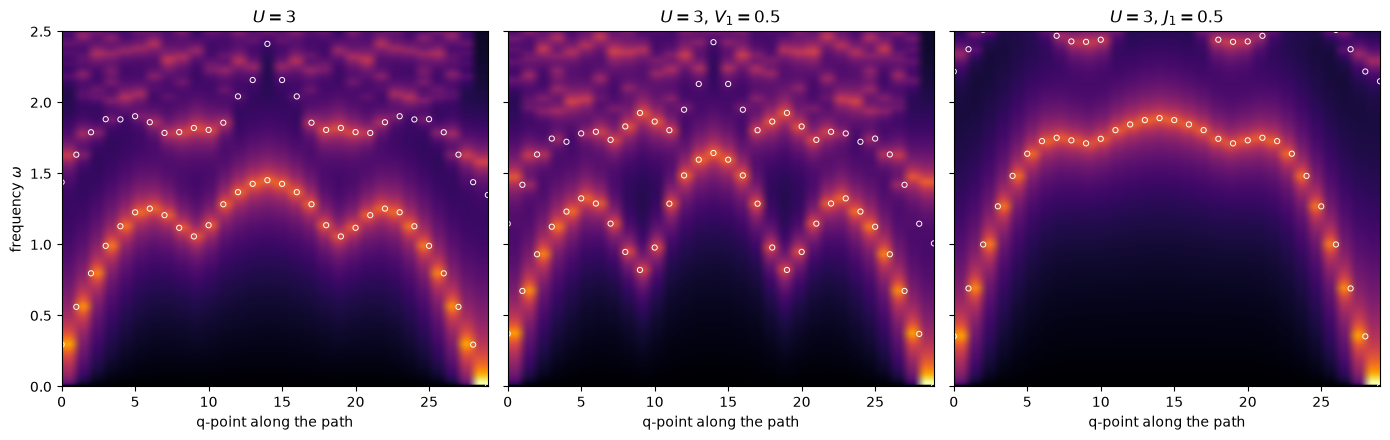

In [2]:
nk = 6 # the same k-mesh for the mean field and for the response
g = geometry.honeycomb_lattice()
qpath = g.get_kpath(nk=30) # high-symmetry path
energies = np.linspace(0.,2.5,200) # frequencies
cases = [("$U=3$",dict(U=3.0)),
         ("$U=3$, $V_1=0.5$",dict(U=3.0,V1=0.5)),
         ("$U=3$, $J_1=0.5$",dict(U=3.0,J1=0.5))]
hmfs = [] # store the mean-field Hamiltonians
fig,axs = plt.subplots(1,3,figsize=(14,4.5),sharey=True)
for ax,(label,kw) in zip(axs,cases):
    hmf = VJinteraction(g.get_hamiltonian(),filling=0.5,mf="antiferro",nk=nk,
                        maxerror=1e-10,mix=0.9,**kw).hamiltonian # Neel-ordered insulator
    hmfs.append(hmf)
    S = [] # spectral function, one row per q-point
    for q in qpath:
        es,chi = hmf.get_transverse_spinchi(energies=energies,q=q,delta=3e-2,nk=nk)
        ns = chi.shape[1]//3 # number of sites
        S.append(np.trace(chi[:,0:2*ns,0:2*ns],axis1=1,axis2=2).imag) # Sx and Sy blocks
    S = np.array(S)
    ax.imshow(np.log10(np.abs(S.T)+1e-2),origin="lower",aspect="auto",cmap="inferno",
              extent=[0,len(qpath)-1,energies[0],energies[-1]])
    qt,et = hmf.get_magnon_bands(method="tdhf",nk=nk,nq=30,n=2) # the independent route
    ax.scatter(qt,et.real,facecolors="none",edgecolors="white",s=14,lw=0.7)
    ax.set_ylim(energies[0],energies[-1])
    ax.set_title(label) ; ax.set_xlabel("q-point along the path")
axs[0].set_ylabel(r"frequency $\omega$")
plt.tight_layout()
plt.show()

### The poles of the ladder
`h.get_magnon_bands(method="pair")` finds the frequencies where an eigenvalue of the dressed
kernel crosses zero, the poles of the ladder, and returns them with the residual imaginary part
that says how well defined each one is. The two magnons of the Néel state with $U$ and $V_1$ are
among them, and they agree with the time-dependent Hartree-Fock energies to the resolution of the
frequency grid; the other poles are kernel crossings in the continuum and carry little weight in
the spectral function above.

In [3]:
hmf = hmfs[1] # the mean field with U and V1
qs,ws,gammas = hmf.get_magnon_bands(method="pair",nq=30,energies=np.linspace(1e-3,2.5,200),
                                    delta=1e-3,nk=nk) # poles along the same path
qt,et = hmf.get_magnon_bands(method="tdhf",nk=nk,nq=30,n=2) # the two magnon branches
for iq in [5,10,14]: # a few points of the path
    tdhf = np.sort(et[qt==iq].real)
    pair = ws[qs==iq]
    closest = [pair[np.argmin(np.abs(pair-e))] for e in tdhf] # the pole nearest each magnon
    print("q-point %2d | tdhf magnons ="%iq,np.round(tdhf,4),"| pair-basis poles =",np.round(closest,4))

q-point  5 | tdhf magnons = [1.3244 1.7815] | pair-basis poles = [1.3243 1.7814]
q-point 10 | tdhf magnons = [0.9781 1.8649] | pair-basis poles = [0.978  1.8648]
q-point 14 | tdhf magnons = [1.6436 2.4236] | pair-basis poles = [1.6436 2.4234]
